# Convolutional Neural Network
---

![Cnn](../picture/CNN.jpeg)

A Convolutional Neural Network (ConvNet/CNN) is a Deep Learning algorithm which can take in an input image, assign importance (learnable weights and biases) to various aspects/objects in the image and be able to differentiate one from the other. The pre-processing required in a ConvNet is much lower as compared to other classification algorithms. While in primitive methods filters are hand-engineered, with enough training, ConvNets have the ability to learn these filters/characteristics.

The architecture of a ConvNet is analogous to that of the connectivity pattern of Neurons in the Human Brain and was inspired by the organization of the Visual Cortex. Individual neurons respond to stimuli only in a restricted region of the visual field known as the Receptive Field. A collection of such fields overlap to cover the entire visual area.[Soure](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53)

![A CNN sequence to classify handwritten digits](../picture/1_uAeANQIOQPqWZnnuH-VEyw.jpeg )
---

In [2]:
# Import librarys
# normal 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# open file
from IPython.display import Image
import os
import PIL

# model CNN (Deep learning network)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense,\
GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Create function plot loss function and accuracy score graph
def plot_graph(model_values):
    ''' 
    Input : Model_values of keras.callbacks.History
    Return : Graph of Loss function and accuracy score between training dataset and vaildation dataset
    '''
    # Subplots
    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(model_values.history['loss'], label='Training Loss');
    plt.plot(model_values.history['val_loss'], label='Testing Loss');
    plt.legend(fontsize=12, loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss');
    
    # Plot MSE
    plt.subplot(1, 2, 2)
    
    plt.plot(model_values.history['accuracy'], label='Training Accuracy')
    plt.plot(model_values.history['val_accuracy'], label='Validation Accuracy')
    
    plt.legend(fontsize=12, loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy');

### 00 First, check GPU.
---

In [4]:
# https://www.tensorflow.org/guide/keras/sequential_model
# Due to we use Keras Sequential API, 
# We want to check GPU first before training our model for 
# impore efficiency and reduce time. 
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16275678501948145775
xla_global_id: -1
]


### 01 Open datasets
---

In [5]:
import os
import shutil
import random

# Define dataset path
base_dir = r"D:\Data_Set"

# Define train, valid, and test directories
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

# Create train, valid, and test folders if they don’t exist
for folder in [train_dir, valid_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# List of class folders (cocci, healthy, ncd, salmo)
class_names = ["cocci", "healthy", "ncd", "salmo"]

# Split ratios
train_ratio = 0.7
valid_ratio = 0.2
test_ratio = 0.1

# Move images into train, valid, and test folders
for class_name in class_names:
    class_path = os.path.join(base_dir, class_name)
    
    if not os.path.exists(class_path):
        print(f"Skipping {class_name}, folder not found!")
        continue
    
    # Get all image files in class folder
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    
    # Shuffle images for random distribution
    random.shuffle(images)

    # Compute split sizes
    train_size = int(len(images) * train_ratio)
    valid_size = int(len(images) * valid_ratio)

    # Split dataset
    train_images = images[:train_size]
    valid_images = images[train_size:train_size + valid_size]
    test_images = images[train_size + valid_size:]

    # Create class folders in train, valid, test
    for folder in [train_dir, valid_dir, test_dir]:
        os.makedirs(os.path.join(folder, class_name), exist_ok=True)

    # Move images to respective folders
    for img in train_images:
        shutil.move(os.path.join(class_path, img), os.path.join(train_dir, class_name, img))
    
    for img in valid_images:
        shutil.move(os.path.join(class_path, img), os.path.join(valid_dir, class_name, img))
    
    for img in test_images:
        shutil.move(os.path.join(class_path, img), os.path.join(test_dir, class_name, img))

    # Remove empty original class folders
    os.rmdir(class_path)

print("✅ Data restructuring complete!")

Skipping cocci, folder not found!
Skipping healthy, folder not found!
Skipping ncd, folder not found!
Skipping salmo, folder not found!
✅ Data restructuring complete!


### 02 Preprocessing image dataset 
---

In [6]:
# Set parameter of image 
# We use input small size image because reduce size of model 
batch_size = 50 # Set the batch size for epoch cycle
img_height = 128 # Set the height of the picture
img_width = 128 # Set the width of the picture

# Rescale pixel to reduce image size before using in model
data_gen_train = ImageDataGenerator(rescale=1/255.)
data_gen_valid = ImageDataGenerator(rescale=1/255.)
data_gen_test = ImageDataGenerator(rescale=1/255.)

In [7]:
# Create training dataset 
train_dataset = data_gen_train.flow_from_directory(train_dir,
                                                   class_mode="categorical",
                                                   target_size=(img_height, img_width),
                                                   batch_size=batch_size)
 

# Create validation dataset 
valid_dataset = data_gen_valid.flow_from_directory(valid_dir,
                                                   class_mode="categorical",
                                                   target_size=(img_height, img_width),
                                                   batch_size=batch_size)

# Create testing dataset 
test_dataset = data_gen_test.flow_from_directory(test_dir,
                                                   class_mode="categorical",
                                                   target_size=(img_height, img_width),
                                                   batch_size=batch_size)


Found 8478 images belonging to 4 classes.
Found 2421 images belonging to 4 classes.
Found 1215 images belonging to 4 classes.


In [8]:
# Classes in training dataset
print(pd.Series(train_dataset.classes).value_counts(normalize = True).mul(100))
print(train_dataset.class_indices)

2    46.874263
3    18.789809
0    17.362586
1    16.973343
Name: proportion, dtype: float64
{'cocci': 0, 'healthy': 1, 'ncd': 2, 'salmo': 3}


In [9]:
# Classes in validation dataset
pd.Series(valid_dataset.classes).value_counts()
# Class 0 : cocci
# Class 1 : healthy
# Class 2 : ncd 
# Class 3 : salmo

2    1135
3     455
0     420
1     411
Name: count, dtype: int64

In [10]:
# Classes in training dataset
pd.Series(test_dataset.classes).value_counts()

2    569
3    228
0    211
1    207
Name: count, dtype: int64

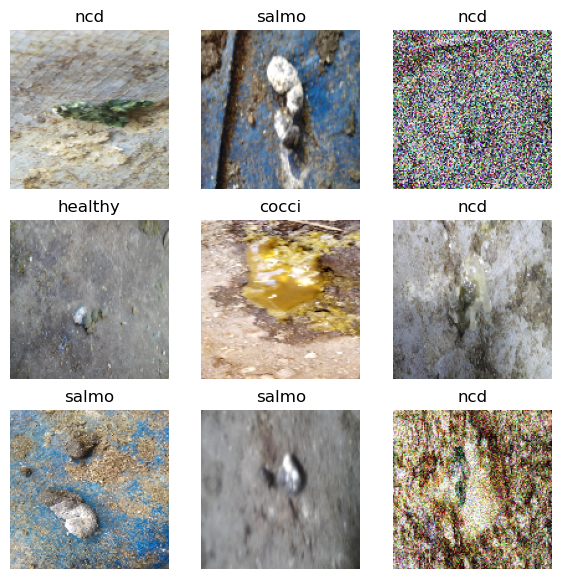

In [11]:
# Show some image samples from the training dataset
import numpy as np
import matplotlib.pyplot as plt

# Fetch one batch of images and labels
images, labels_class = next(iter(train_dataset))

# Get class indices mapping
classes = train_dataset.class_indices
class_indices_rev = {v: k for k, v in classes.items()}  # Reverse mapping for lookup

# Plot images
plt.figure(figsize=(7, 7))
for i in range(min(9, len(images))):  # Ensure we don't exceed batch size
    argmax_label = np.argmax(labels_class[i])  # Get predicted class index
    
    # Get the corresponding label safely
    label = class_indices_rev.get(argmax_label, "Unknown")  
    
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))  # Convert to displayable format
    plt.title(label)
    plt.axis("off")

plt.show()


In [12]:
# Check if images contain any data before accessing
if len(images) > 0:
    print("Max pixel value:", images[0].max())
    print("Min pixel value:", images[0].min())
else:
    print("Warning: No images found in the batch. Check data loading.")


Max pixel value: 1.0
Min pixel value: 0.09019608


---

### 03 CNN model training 
---

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Define model
model = Sequential([
    # Input layer
    Input(shape=(128, 128, 3)),  
    
    # First convolutional layer
    Conv2D(16, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    # Second convolutional layer
    Conv2D(32, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    # Flattening the layers
    Flatten(),
    Dense(64, activation='relu', kernel_initializer='he_uniform'),
    
    # Avoid overfitting
    Dropout(0.5),

    # Output layer
    Dense(4, activation='softmax')  # Assuming 4 classes
])

# Compile the model
model.compile(loss="categorical_crossentropy", 
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Summary to check model structure
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 32768)             0         
                                                                 
 dense (Dense)               (None, 64)                2

In [14]:
# we have 2,102,564 nodes for training
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 32768)             0         
                                                                 
 dense (Dense)               (None, 64)                2

In [15]:
import os
import tensorflow as tf

# Define a safe absolute path to store checkpoints (Modify this if needed)
base_dir = os.path.expanduser("~/deep_learning_checkpoints")  # Creates a folder in the user's home directory
checkpoint_path = os.path.join(base_dir, "cnn_model_cp.weights.h5")

# Ensure the checkpoint directory exists
os.makedirs(base_dir, exist_ok=True)  # Create only if it doesn't exist

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,  # Saving only weights
                                                 verbose=1)

print(f"Checkpoint will be saved at: {checkpoint_path}")



Checkpoint will be saved at: C:\Users\Muhammad Salman/deep_learning_checkpoints\cnn_model_cp.weights.h5


In [16]:
from PIL import ImageFile

# Allow truncated images to be loaded instead of causing an error
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Training model
# Make sure checkpoint_path is correctly saved
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=valid_dataset,
    callbacks=[cp_callback]
)

Epoch 1/5
170/170 [==============================] - ETA: 0s - loss: 1.0570 - accuracy: 0.5750   
Epoch 1: saving model to C:\Users\Muhammad Salman/deep_learning_checkpoints\cnn_model_cp.weights.h5
170/170 [==============================] - 1800s 11s/step - loss: 1.0570 - accuracy: 0.5750 - val_loss: 0.7074 - val_accuracy: 0.7381
Epoch 2/5
170/170 [==============================] - ETA: 0s - loss: 0.6763 - accuracy: 0.6929   
Epoch 2: saving model to C:\Users\Muhammad Salman/deep_learning_checkpoints\cnn_model_cp.weights.h5
170/170 [==============================] - 1636s 10s/step - loss: 0.6763 - accuracy: 0.6929 - val_loss: 0.5463 - val_accuracy: 0.7993
Epoch 3/5
170/170 [==============================] - ETA: 0s - loss: 0.5873 - accuracy: 0.7611   
Epoch 3: saving model to C:\Users\Muhammad Salman/deep_learning_checkpoints\cnn_model_cp.weights.h5
170/170 [==============================] - 1587s 9s/step - loss: 0.5873 - accuracy: 0.7611 - val_loss: 0.4835 - val_accuracy: 0.8439
Epoch

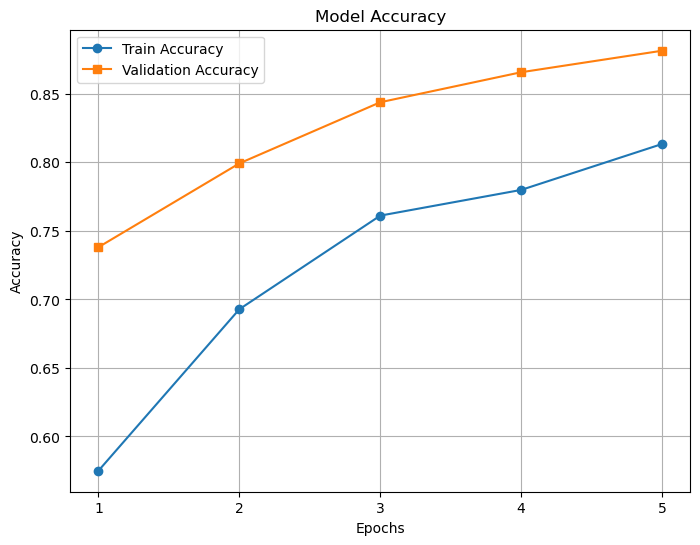

In [17]:
# plot graph 
import matplotlib.pyplot as plt

def plot_graph(history):
    # Ensure history contains accuracy data
    if 'accuracy' not in history.history or 'val_accuracy' not in history.history:
        print("Error: Accuracy data not found in history.")
        return

    epochs_range = range(1, len(history.history['accuracy']) + 1)  # Generate epoch numbers

    plt.figure(figsize=(8, 6))

    # Plot training & validation accuracy
    plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', marker='s')

    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs_range)  # Ensure epoch numbers are displayed correctly
    plt.legend()
    plt.grid(True)

    # Show the graph
    plt.show()

# Call the function to display the graph
plot_graph(history)


# Slightly overfit between training and validation 
# Final accuracy after training 25 epochs was score in training, 0.94% 
# and vaildaion 0.88%
# Loss function after training 25 epochs was score in training, 0.14% 
# and vaildaion 0.45%

# Good performance! but not enough!  

In [18]:
# create dataframe to save in .csv file
hist_df = pd.DataFrame(history.history) 
hist_df.head()

,loss,accuracy,val_loss,val_accuracy
0,1.056980,0.575018,0.707431,0.738125
1,0.676268,0.692852,0.546339,0.799257
2,0.587286,0.761146,0.483476,0.843866
3,0.556978,0.779901,0.435679,0.865758
4,0.454813,0.813399,0.344457,0.881454


In [19]:
import os

# Define model save path in a safe location
model_path = "D:/cnn_model.h5"

# Ensure directory exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
model.save(model_path)


---

In [20]:
import os
import pandas as pd

# Define history save path
hist_csv_file = "D:/cnn_history/history_cnn16.csv"

# Ensure the directory exists
os.makedirs(os.path.dirname(hist_csv_file), exist_ok=True)

# Convert history to DataFrame (if not already a DataFrame)
hist_df = pd.DataFrame(history.history)

# Save history to CSV
hist_df.to_csv(hist_csv_file, index=False)

print(f"History saved successfully at {hist_csv_file}")


History saved successfully at D:/cnn_history/history_cnn16.csv
